# May 2026 Batch Experiment Analysis
Analysis and comparison of different repair algorithms: `weighted_vc`, `vanilla_vc`, `classic_vc`, and `ilp`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 8]

# Load aggregated data
df = pd.read_csv('../experiments_may2026_batch.csv')

print(f"Total records: {len(df)}")
print("Records by Dataset:", df.groupby('dataset').size().to_dict())
print("Records by Repairer:", df.groupby('repairer').size().to_dict())

df.head()

Total records: 174
Records by Dataset: {'adult': 45, 'census': 42, 'compas': 42, 'tax': 45}
Records by Repairer: {'ClassicVCRepairer': 36, 'ILPRepairer': 66, 'VanillaVCRepairer': 36, 'WeightedVCRepairer': 36}


,dataset,experiment_name,experiment_id,timestamp,meta_loader,meta_synthesizer,meta_obtainer,meta_repairer,meta_synthesizer_params_model_path,meta_synthesizer_params_size,...,loss_function_synthetic_size_component,loss_function_synthetic_marginal_component,loss_function_repaired_total,loss_function_repaired_size_component,loss_function_repaired_marginal_component,marginal_generation_quality_avg_relative_error,marginal_selection_quality_precision_at_k,marginal_selection_quality_overlap_count,marginal_selection_quality_k,meta_repairer_params_use_marginals
0,adult,may_2026_batch,126fb5cd,2026-05-08T11:43:55.391951,FileLoader,SmartNoiseModelLoader,TopKObtainer,ILPRepairer,models/adult_aim.pkl,1000,...,0.0,0.013747,0.027672,0.044,0.011343,NaN,NaN,NaN,NaN,False
1,adult,may_2026_batch,1985bfd9,2026-05-08T10:26:03.332907,FileLoader,SmartNoiseModelLoader,TopKObtainer,ILPRepairer,models/adult_patectgan.pkl,1000,...,0.0,0.660585,0.813507,0.962,0.665014,NaN,NaN,NaN,NaN,False
2,adult,may_2026_batch,2529a573,2026-05-08T09:42:41.347953,FileLoader,SmartNoiseModelLoader,TopKObtainer,ILPRepairer,models/adult_mst.pkl,1000,...,0.0,0.026259,0.022324,0.019,0.025649,NaN,NaN,NaN,NaN,False
3,adult,may_2026_batch,28edc987,2026-05-08T11:43:49.965193,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim.pkl,1000,...,0.0,0.013747,0.027672,0.044,0.011343,NaN,NaN,NaN,NaN,NaN
4,adult,may_2026_batch,2dd93aeb,2026-05-08T11:43:55.151444,FileLoader,SmartNoiseModelLoader,TopKObtainer,ILPRepairer,models/adult_aim.pkl,1000,...,0.0,0.012810,0.027981,0.045,0.010962,NaN,NaN,NaN,NaN,False


## Comparison of Metrics by Repairer

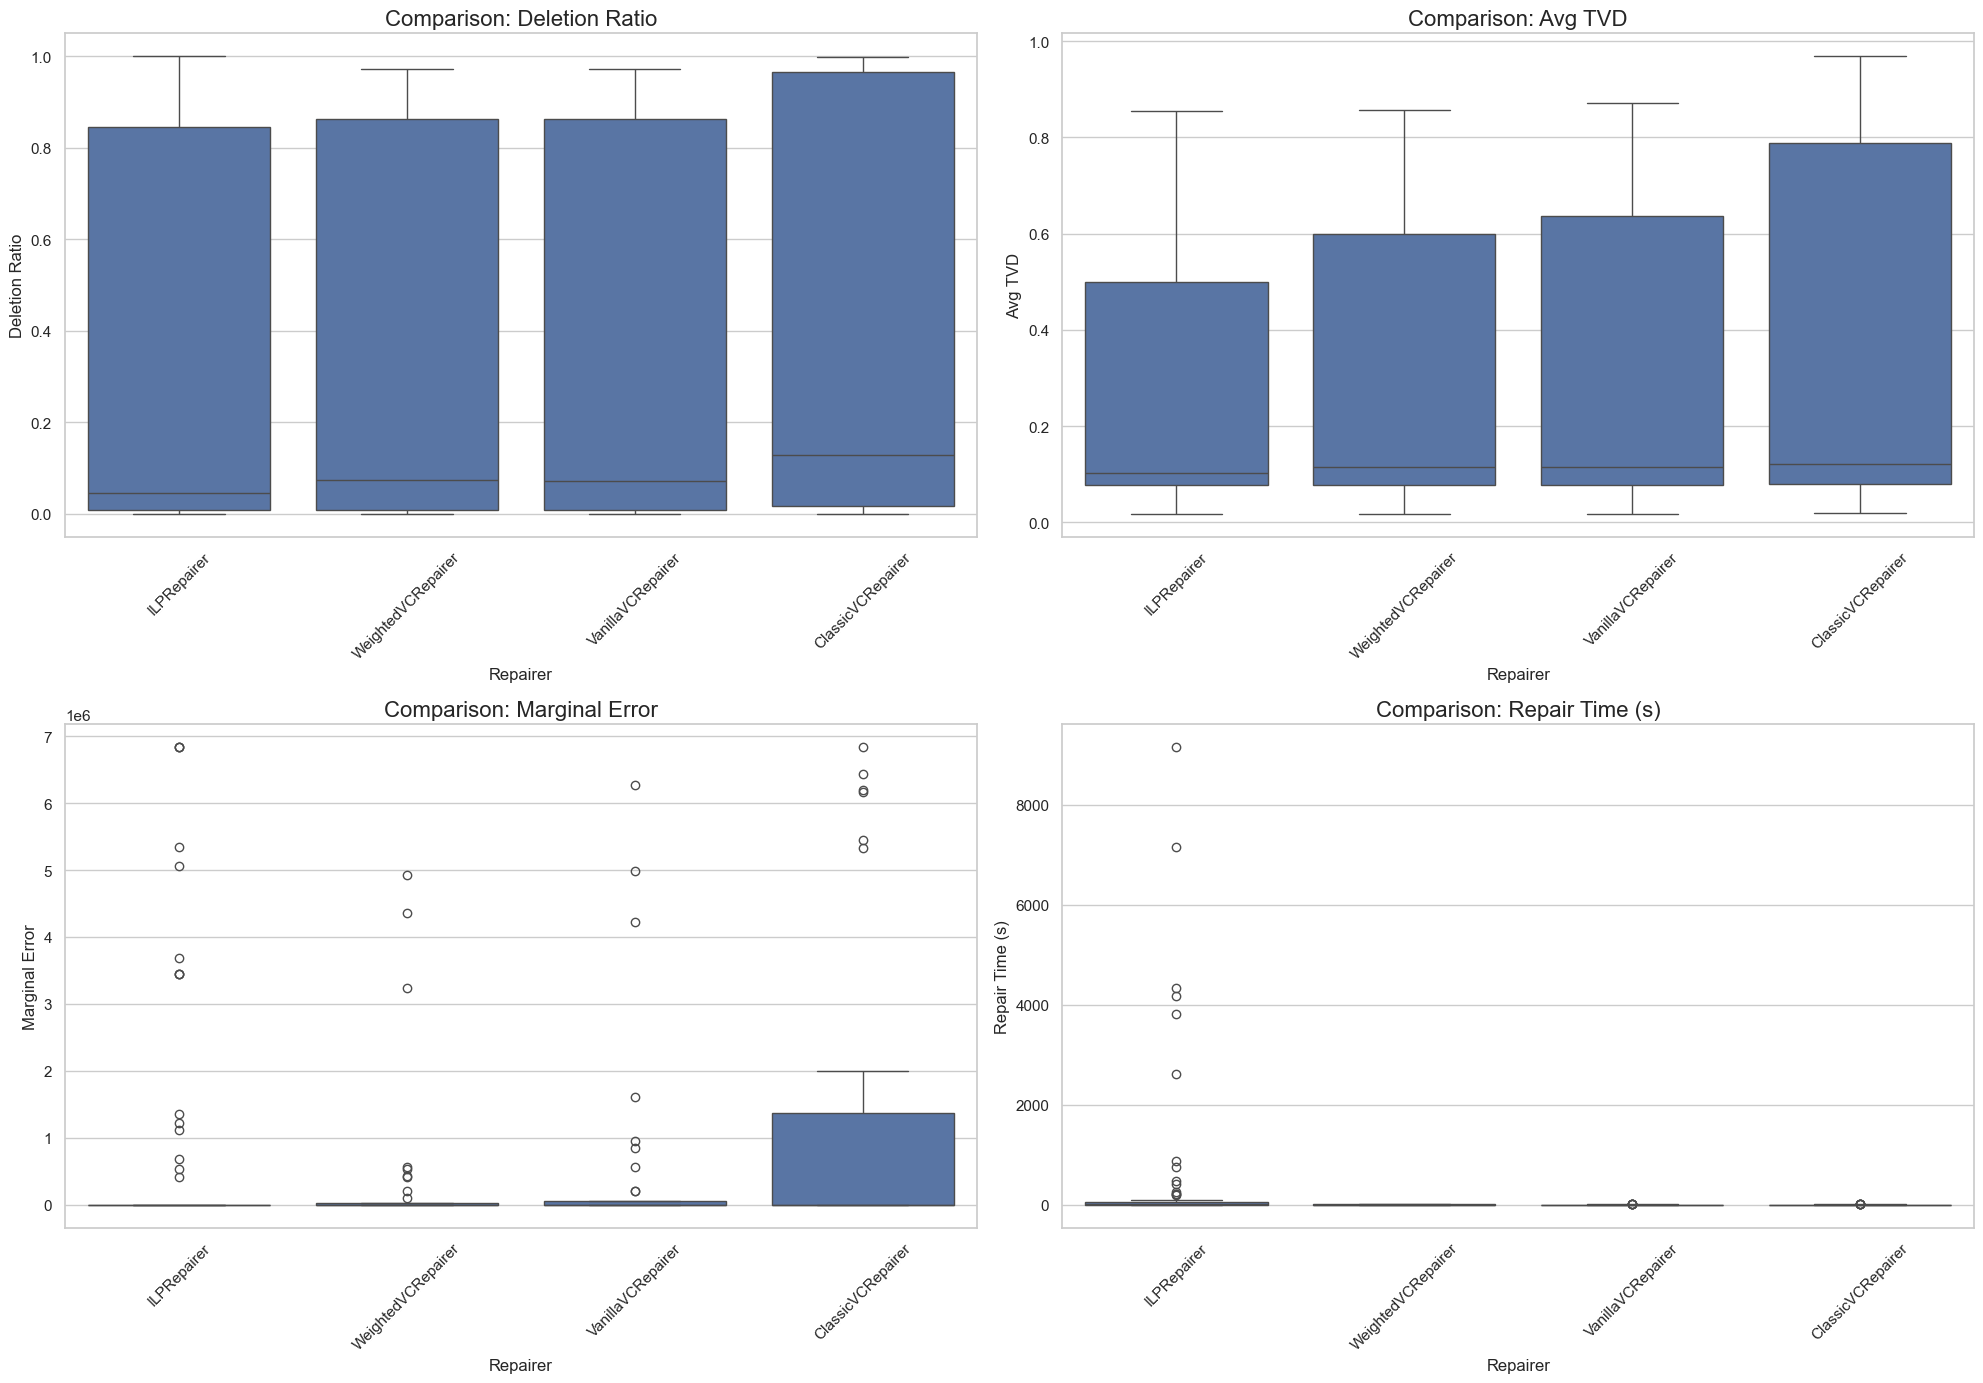

In [2]:
metrics = {
    'deletion_ratio_ratio': 'Deletion Ratio',
    'tvd_2way_repaired_avg': 'Avg TVD',
    'marginals_error_repaired_avg': 'Marginal Error',
    'runtime_repairing': 'Repair Time (s)'
}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, (col, name) in enumerate(metrics.items()):
    sns.boxplot(data=df, x='repairer', y=col, ax=axes[i])
    axes[i].set_title(f'Comparison: {name}', fontsize=16)
    axes[i].set_ylabel(name)
    axes[i].set_xlabel('Repairer')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Performance by Dataset

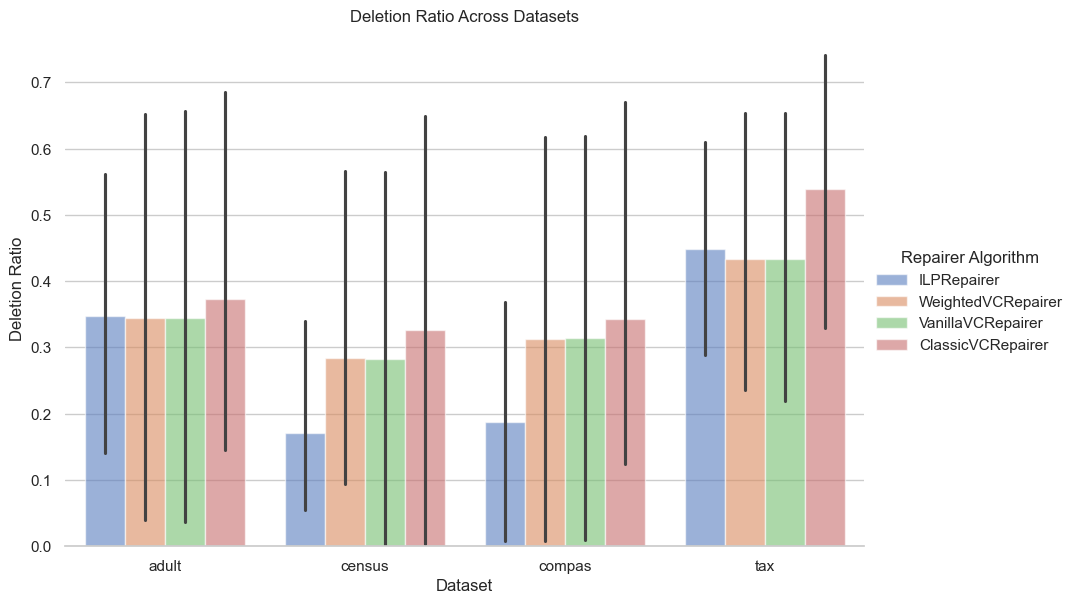

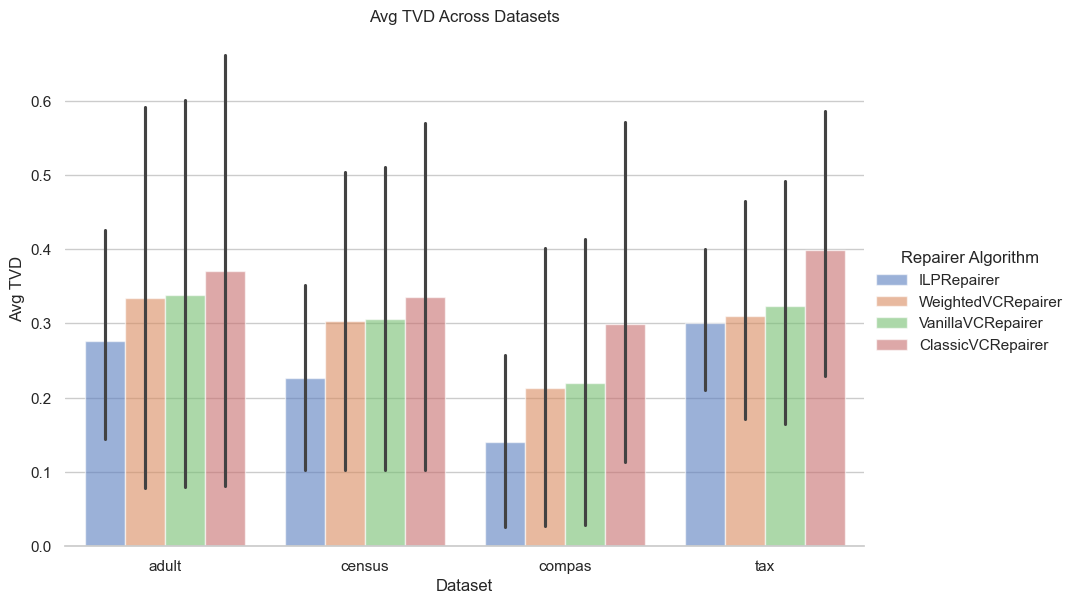

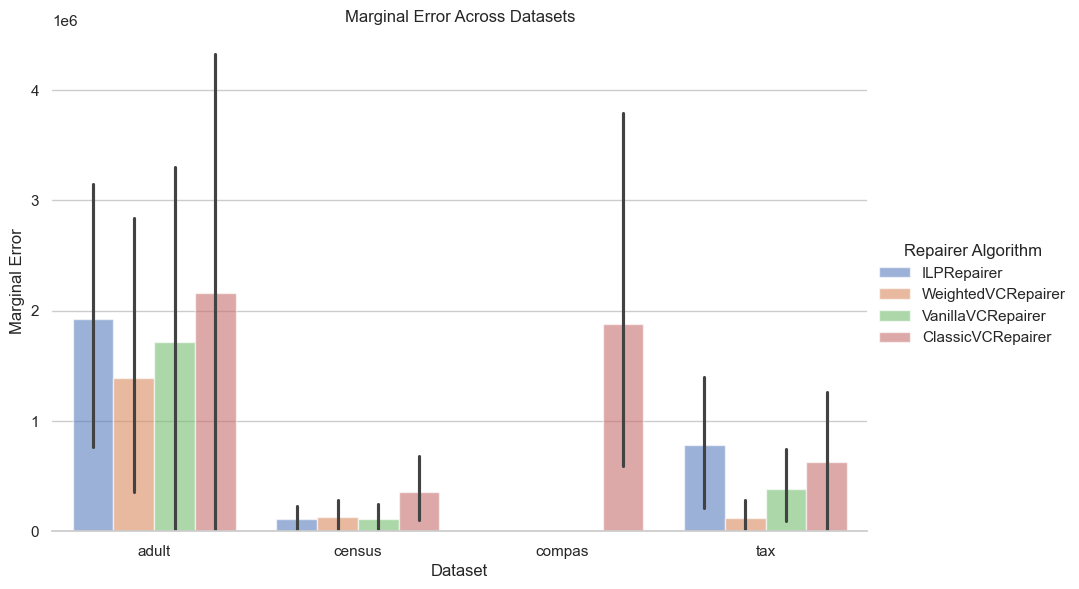

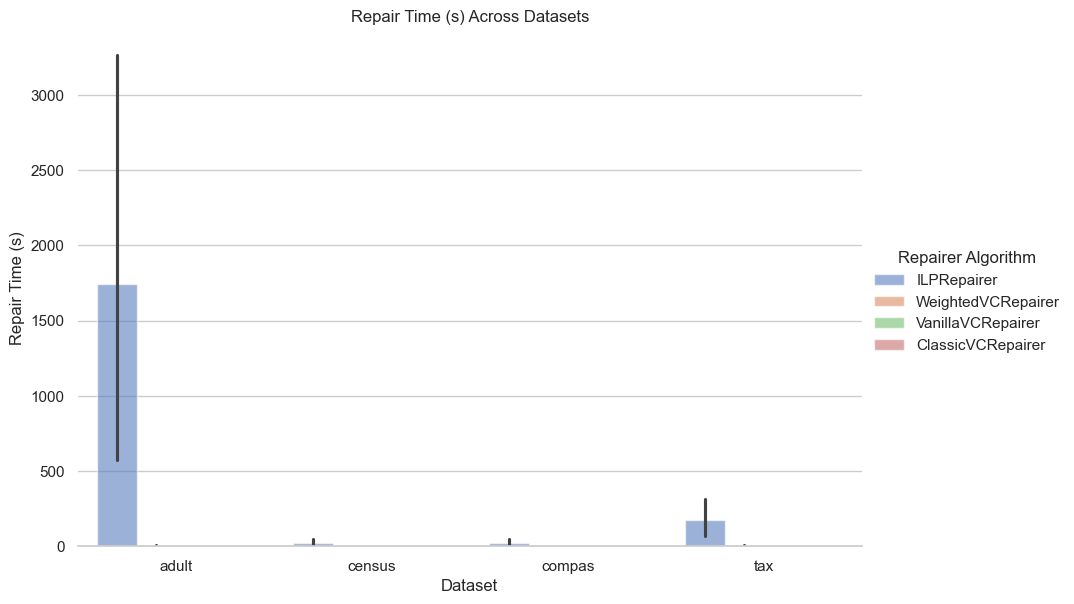

In [3]:
for metric_col, metric_name in metrics.items():
    g = sns.catplot(
        data=df, 
        kind="bar", 
        x="dataset", 
        y=metric_col, 
        hue="repairer",
        palette="muted", 
        alpha=.6, 
        height=6, 
        aspect=1.5
    )
    g.despine(left=True)
    g.set_axis_labels("Dataset", metric_name)
    g.legend.set_title("Repairer Algorithm")
    plt.title(f"{metric_name} Across Datasets")
    plt.show()